<a href="https://colab.research.google.com/github/mahmoodtt1/OR/blob/main/Data_analysis_for_Cars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import kagglehub
import os
import pandas as pd


pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


# Download and get path
path = kagglehub.dataset_download("nehalbirla/vehicle-dataset-from-cardekho")
print("Path to dataset files:", path)

# List all files in the folder
files = os.listdir(path)
print("Files:", files)

Path to dataset files: /kaggle/input/vehicle-dataset-from-cardekho
Files: ['car data.csv', 'car details v4.csv', 'CAR DETAILS FROM CAR DEKHO.csv', 'Car details v3.csv']


Load the data if you have the address!

In [32]:
df = pd.read_csv(os.path.join(path, "car data.csv"))
print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Kms_Driven Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Seller_Type Transmission  Owner  
0      Dealer       Manual      0  
1      Dealer       Manual      0  
2      Dealer       Manual      0  
3      Dealer       Manual      0  
4      Dealer       Manual      0  




---
---

## Quickly plot the data to see the relationships!


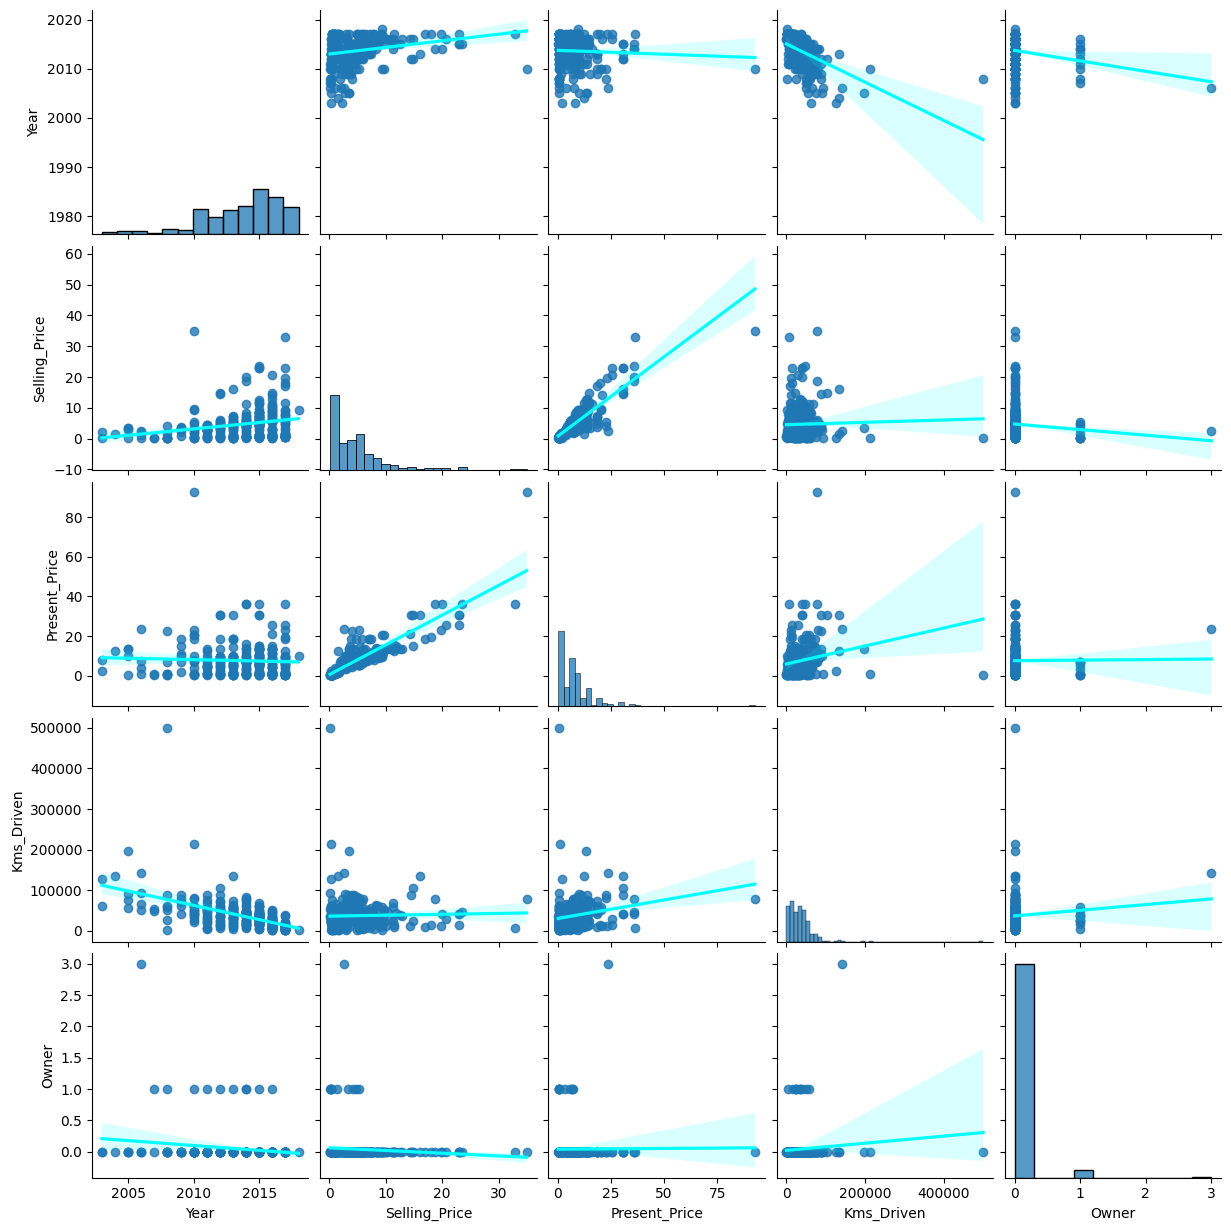

In [21]:
sns.pairplot(df, kind='reg', plot_kws={'line_kws' : {'color': 'cyan'}})
plt.show()



# Group the data to see certain relationships if needed!

<Axes: xlabel='Present_Price', ylabel='Selling_Price'>

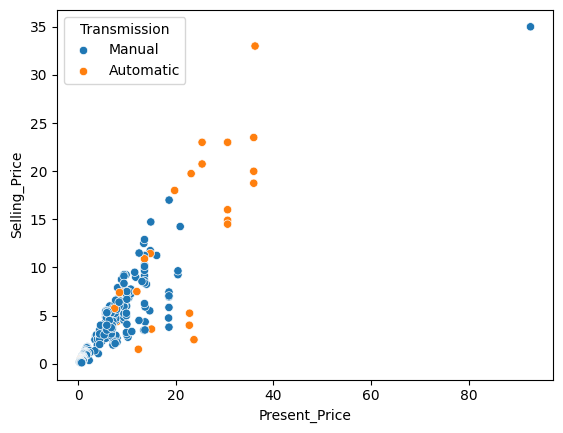

In [18]:
sns.scatterplot(x=df['Present_Price'], y=df['Selling_Price'], hue=df['Transmission'])

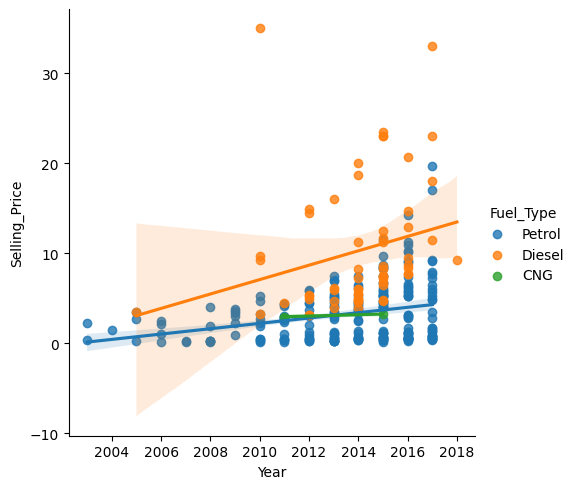

In [15]:
sns.lmplot(x="Year", y="Selling_Price", hue="Fuel_Type", data=df)


check for null values and empty cells first! if you have any, remove them with drop.na()

In [19]:
pd.isnull(df).any()

,0
Car_Name,False
Year,False
Selling_Price,False
Present_Price,False
Kms_Driven,False
Fuel_Type,False
Seller_Type,False
Transmission,False
Owner,False


In [20]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [22]:
fuel_group = df.groupby('Fuel_Type')
fuel_mean = fuel_group['Selling_Price'].mean()
fuel_mean


,Selling_Price
Fuel_Type,
CNG,3.100000
Diesel,10.278500
Petrol,3.264184


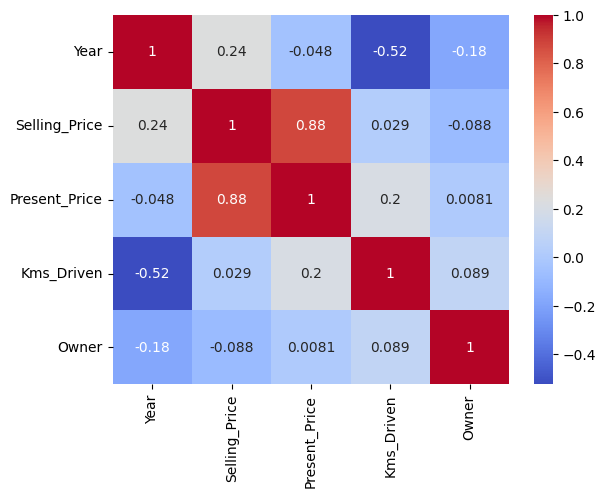

In [24]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Plot heatmap
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

ok lets do the regression.

Car_Name          object
Year               int64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [33]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# Step 1: Drop 'Car_Name' (not useful for regression)
df = df.drop('Car_Name', axis=1)

# Step 2: Encode categorical features using get_dummies
df_encoded = pd.get_dummies(df, columns=['Fuel_Type', 'Seller_Type', 'Transmission'], drop_first=True)

# Step 3: Define features and target
X = df_encoded.drop('Selling_Price', axis=1)
y = df_encoded['Selling_Price']

# Step 4: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 5: Train the regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Step 6: Predict and evaluate
y_pred = model.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred))

# Step 7: Coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients.sort_values(by="Coefficient", ascending=False))



R² Score: 0.8489813024897594
RMSE: 3.478803970641293
                  Feature  Coefficient
4        Fuel_Type_Diesel     2.533273
5        Fuel_Type_Petrol     0.738464
1           Present_Price     0.429153
0                    Year     0.353801
2              Kms_Driven    -0.000006
3                   Owner    -0.903760
6  Seller_Type_Individual    -1.190593
7     Transmission_Manual    -1.639022


                  Feature  Standardized Coefficient
1           Present_Price                  3.772700
0                    Year                  1.134737
4        Fuel_Type_Diesel                  0.986741
6  Seller_Type_Individual                 -0.535589
7     Transmission_Manual                 -0.491591
2              Kms_Driven                 -0.272269
5        Fuel_Type_Petrol                  0.245746
3                   Owner                 -0.166858


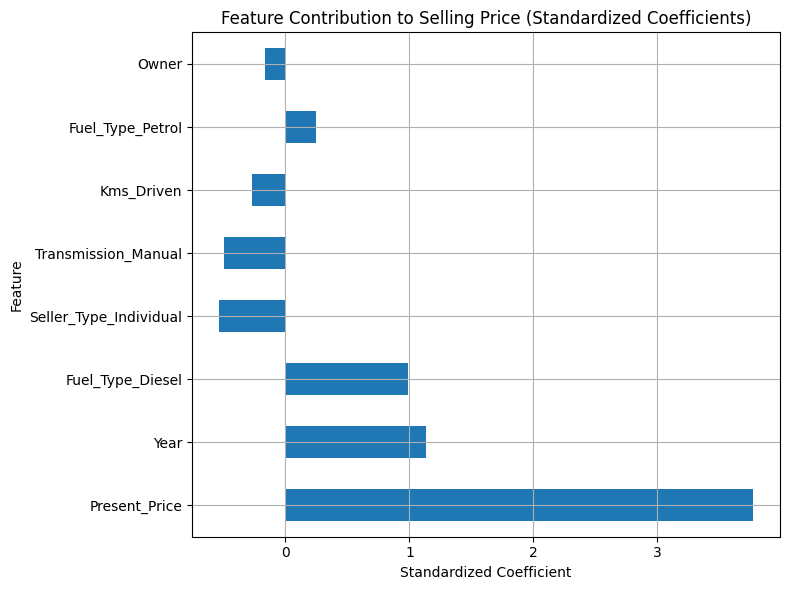

In [37]:
from sklearn.preprocessing import StandardScaler

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Re-train model on scaled data
model_std = LinearRegression()
model_std.fit(X_scaled, y)

# Show standardized coefficients
std_coeffs = pd.DataFrame({
    'Feature': X.columns,
    'Standardized Coefficient': model_std.coef_
}).sort_values(by='Standardized Coefficient', key=abs, ascending=False)

print(std_coeffs)


std_coeffs.plot(kind='barh', x='Feature', y='Standardized Coefficient', figsize=(8,6), legend=False)
plt.title("Feature Contribution to Selling Price (Standardized Coefficients)")
plt.xlabel("Standardized Coefficient")
plt.grid(True)
plt.tight_layout()
plt.show()


In [39]:
print(X_with_const.dtypes)


const                     float64
Year                        int64
Present_Price             float64
Kms_Driven                  int64
Owner                       int64
Fuel_Type_Diesel             bool
Fuel_Type_Petrol             bool
Seller_Type_Individual       bool
Transmission_Manual          bool
dtype: object


In [40]:
import statsmodels.api as sm

# Add intercept manually
X_with_const = sm.add_constant(X)
# Convert all bool columns to int
X_with_const = X_with_const.astype({col: int for col in X_with_const.select_dtypes('bool').columns})

# Fit model
ols_model = sm.OLS(y, X_with_const).fit()

# Show full summary (p-values, R², F-stat, etc.)
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:          Selling_Price   R-squared:                       0.883
Model:                            OLS   Adj. R-squared:                  0.879
Method:                 Least Squares   F-statistic:                     274.3
Date:                Fri, 25 Jul 2025   Prob (F-statistic):          5.71e-131
Time:                        00:35:06   Log-Likelihood:                -593.62
No. Observations:                 301   AIC:                             1205.
Df Residuals:                     292   BIC:                             1239.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   -789